## Data acquisition

! Speed reading might vary with :
* Thymio
* Wireless / USB dongle
* Speed target
* Surface (adherence)

In [42]:
!python3 -m pip install --upgrade tdmclient

In [49]:
from tdmclient import ClientAsync

n_samples = 500
wait_time = 1e-2    # motor.speed sensor refresh period (cf. Cheat Sheet)
target_speed = 50

data = []
 
with ClientAsync() as client:
    with await client.lock() as node:
        
        await node.set_variables({
            "motor.left.target": [target_speed],
            "motor.right.target": [target_speed]
            })
                
        for i in range(n_samples):
            await client.sleep(wait_time)
            client.aw(node.wait_for_variables())
            data.append(({"ground_sensor1":node["prox.ground.reflected"][0],
                          "ground_sensor2":node["prox.ground.reflected"][1],  
                            "left_speed":node["motor.left.speed"],
                            "right_speed":node["motor.right.speed"]}))

        await node.set_variables({
            "motor.left.target": [0],
            "motor.right.target": [0]
            })

        data = {'name': node.props["name"], 'target_speed': target_speed, 'data': data}

In [44]:
# Save to file
import json
import os

os.makedirs('measurements', exist_ok=True)
with open('measurements/speed.json', 'w') as fout:
    json.dump(data, fout)
    

## Data processing

### Speed conversion factor

name: Thymio 548


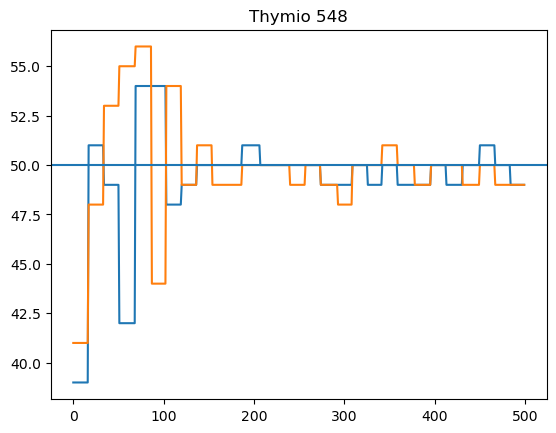

In [47]:
import numpy as np
import matplotlib.pyplot as plt

with open('measurements/speed.json', 'r') as file:
    data = json.load(file)
    name = data['name']
    target_speed = data['target_speed']
    print(f"name: {name}")
    data = data['data']


left_speed = np.array([sample["left_speed"] for sample in data])
right_speed = np.array([sample["right_speed"] for sample in data])
ground_sensor1 = np.array([sample["ground_sensor1"] for sample in data])
ground_sensor2 = np.array([sample["ground_sensor2"] for sample in data])
ground_sensor = (ground_sensor1 + ground_sensor2)/2

plt.plot(left_speed)
plt.plot(right_speed)
plt.axhline(target_speed)
plt.title(name)
plt.show()


#plt.plot(ground_sensor)
#plt.show()

# Cut transient acceleration
right_speed = right_speed[200:]
left_speed = left_speed[200:]

### Speed measurement variance

In [48]:
speed_to_mms = 0.45         

avg_speed = (left_speed+right_speed)/2
std_speed = np.std(avg_speed/speed_to_mms)  # [mm^2/s^2]
cov_speed = np.cov(np.vstack((right_speed, left_speed))/speed_to_mms)

print(cov_speed)        # this will be R_encoder [mm^2/s^2]

[[2.28245042 0.75103569]
 [0.75103569 1.88259906]]
